In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter
import matplotlib.pyplot as plt

```python
adam_basic = {
    "algorithm": "adam",
    "max_steps": 1000,
}

adam_detailed = {
    "algorithm": "adam",
    "max_steps": 2000,
    "patience": 20,              # Early stopping patience
    "ftol": 1e-8,                # Convergence tolerance
    "learning_rate": 5e-4,       # Base learning rate
    "steps_file": 50,            # Log interval
}

adam_with_scheduler = {
    "algorithm": "adam",
    "max_steps": 5000,
    "learning_rate": 1e-3,
    "use_scheduler": True,       # Enable learning rate scheduler
    "schedule_type": "cosine",   # Cosine annealing schedule
    "warmup_steps": 500,         # Linear warmup period
    "decay_steps": 4500,         # Steps over which to decay
    "peak_value": 2e-3,          # Maximum learning rate
    "end_value": 1e-6,           # Minimum learning rate
}

adabelief_with_scheduler = {
    "algorithm": "adabelief",
    "max_steps": 10000,
    "learning_rate": 1e-3,
    "use_scheduler": True,
    "schedule_type": "exponential",
    # other parameters...
}

lbfgs_basic = {
    "algorithm": "lbfgs",
    "max_steps": 100,           # Typically needs fewer steps
    "patience": 5,
    "ftol": 1e-7,
}

lbfgs_custom = {
    "algorithm": "lbfgs",
    "max_steps": 200,
    "history_size": 20,         # Larger history size
    "line_search": "zoom",      # Can be "zoom" or "backtracking"
    "steps_file": 5,            # Log more frequently
}
```

In [12]:
jax.config.update("jax_enable_x64", True)
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(1, 100),
    n_T=500,
    n_P=500,
    param_config=param_config,
    loss_name="log",
    log_name="sri.log",
    falloff_type="sri"
)

optax_options = {
    "algorithm": "ISRES",
    "max_eval": 100000,
    "ftol_rel": 1e-10,
    "xtol_rel": 1e-10,
    "patience": 1000,
    "steps_file": 10000
}

initial_sri = refitter.fit(nlopt_options=optax_options)
print(FallOff(initial_sri))

Plog 2 SRI refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (1, 100)
 Loss function: log

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  a: optimizing from default initial value
  b: optimizing from default initial value
  c: optimizing from default initial value
  d: optimizing from default initial value
  e: optimizing from default initial value

Starting optimization
First guess estimate of the parameters:
  SRI parameters (a, b, c, d, e): 1.000, 7.500e+02, 1.500e+03, 1.000, 0.000

  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 4.814e+30, -3.867, 3.108e+03
  Step 0: loss = 2.293842e+00
  Step 10000: loss = 2.142497e+00
  Step 20000: loss = 6.971663e-01
  Step 30000: loss = 9.961713e-02
  Step 40000: loss =

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW / 		1.18891e+30 -3.87730 3.47749e+03 /
 SRI / 9.49485e+01 1.99390e+04 1.35682e+03 1.86044e+00 -1.69993e-01 /


Minimum error: 0.8230309609319854
Maximum error: 1.12322403005292
Average error: 0.038323453914160976


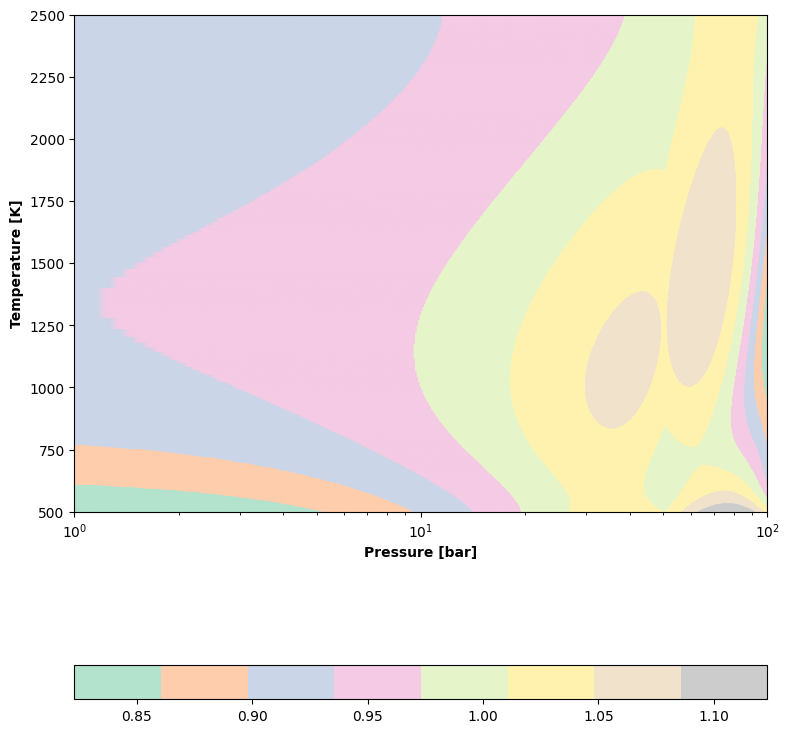

In [13]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_sri)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_falloff_map.T / k_plog_map.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()

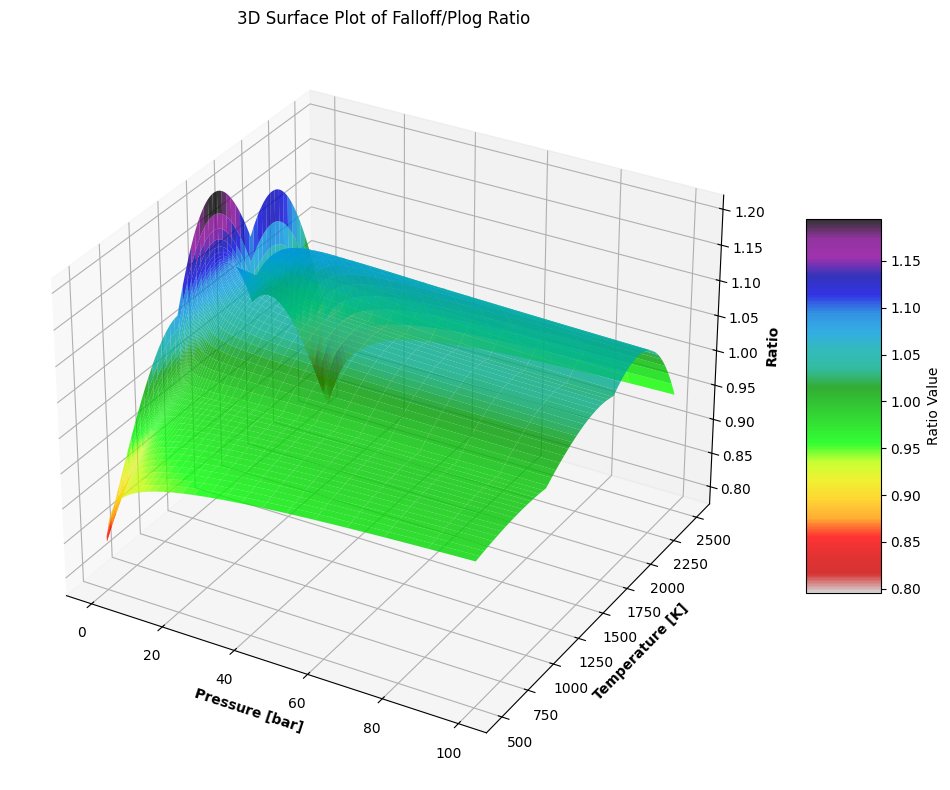

In [11]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np

# Assuming you have your data already calculated:
# T_range, P_range, T_mesh, P_mesh, ratio (from your existing code)

# Create a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# For 3D surface plot, we need to use the meshgrid format
# Convert JAX arrays to NumPy for compatibility if needed
T_mesh_np, P_mesh_np = np.array(T_mesh), np.array(P_mesh)
ratio_np = np.array(ratio)

# Create the surface plot
surf = ax.plot_surface(
    P_mesh_np, T_mesh_np, ratio_np,
    cmap='nipy_spectral_r',
    linewidth=0,
    antialiased=True,
    alpha=0.8
)

# Set log scale for pressure axis
# ax.set_xscale('log')

# Customize the plot
ax.set_xlabel('Pressure [bar]', fontweight='bold')
ax.set_ylabel('Temperature [K]', fontweight='bold')
ax.set_zlabel('Ratio', fontweight='bold')
ax.set_title('3D Surface Plot of Falloff/Plog Ratio')

# Add a color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Ratio Value')

# Adjust the viewing angle for better visualization
# ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()